In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv("Students_Grading_Dataset.csv")

In [ ]:
print("Missing values:\n", df.isnull().sum())

Missing values:
 Student_ID                       0
First_Name                       0
Last_Name                        0
Email                            0
Gender                           0
Age                              0
Department                       0
Attendance (%)                 516
Midterm_Score                    0
Final_Score                      0
Assignments_Avg                517
Quizzes_Avg                      0
Participation_Score              0
Projects_Score                   0
Total_Score                      0
Grade                            0
Study_Hours_per_Week             0
Extracurricular_Activities       0
Internet_Access_at_Home          0
Parent_Education_Level        1794
Family_Income_Level              0
Stress_Level (1-10)              0
Sleep_Hours_per_Night            0
dtype: int64


In [ ]:
df.drop_duplicates(inplace=True)


In [ ]:
df.loc[:, "Attendance (%)"] = df["Attendance (%)"].fillna(df["Attendance (%)"].mean())
df.loc[:, "Assignments_Avg"] = df["Assignments_Avg"].fillna(df["Assignments_Avg"].mean())


In [ ]:
df.loc[:, "Parent_Education_Level"] = df["Parent_Education_Level"].fillna(df["Parent_Education_Level"].mode()[0])


In [ ]:
#Here we are cleaning up string formats (lowercase and strip):
df["Extracurricular_Activities"] = df["Extracurricular_Activities"].str.lower().str.strip()
df["Internet_Access_at_Home"] = df["Internet_Access_at_Home"].str.lower().str.strip()




In [ ]:
print(" Missing values after cleaning:\n", df.isnull().sum())


 Missing values after cleaning:
 Student_ID                    0
First_Name                    0
Last_Name                     0
Email                         0
Gender                        0
Age                           0
Department                    0
Attendance (%)                0
Midterm_Score                 0
Final_Score                   0
Assignments_Avg               0
Quizzes_Avg                   0
Participation_Score           0
Projects_Score                0
Total_Score                   0
Grade                         0
Study_Hours_per_Week          0
Extracurricular_Activities    0
Internet_Access_at_Home       0
Parent_Education_Level        0
Family_Income_Level           0
Stress_Level (1-10)           0
Sleep_Hours_per_Night         0
dtype: int64


In [ ]:
# Step 3:Here we are doing Data Reduction using Attribute Subset Selection

# Here we have Final list of important features (Student_ID removed)
columns_to_keep = [
    'Gender', 'Age', 'Department', 'Attendance (%)', 'Midterm_Score',
    'Final_Score', 'Assignments_Avg', 'Quizzes_Avg', 'Participation_Score',
    'Projects_Score', 'Study_Hours_per_Week', 'Extracurricular_Activities',
    'Internet_Access_at_Home', 'Parent_Education_Level', 'Family_Income_Level',
    'Stress_Level (1-10)', 'Sleep_Hours_per_Night', 'Grade'
]

# Here wer are Createing a new reduced DataFrame
df_reduced = df[columns_to_keep]

# Checking the shape and preview the result
print("Reduced dataset shape:", df_reduced.shape)
df_reduced.head()


Reduced dataset shape: (5000, 18)


,Gender,Age,Department,Attendance (%),Midterm_Score,Final_Score,Assignments_Avg,Quizzes_Avg,Participation_Score,Projects_Score,Study_Hours_per_Week,Extracurricular_Activities,Internet_Access_at_Home,Parent_Education_Level,Family_Income_Level,Stress_Level (1-10),Sleep_Hours_per_Night,Grade
0,Female,22,Engineering,52.29,55.03,57.82,84.220000,74.06,3.99,85.90,6.2,no,yes,High School,Medium,5,4.7,F
1,Male,18,Engineering,97.27,97.23,45.80,74.798673,94.24,8.32,55.65,19.0,no,yes,PhD,Medium,4,9.0,A
2,Male,24,Business,57.19,67.05,93.68,67.700000,85.70,5.05,73.79,20.7,no,yes,Master's,Low,6,6.2,D
3,Female,24,Mathematics,95.15,47.79,80.63,66.060000,93.51,6.54,92.12,24.8,yes,yes,High School,High,3,6.7,A
4,Female,23,CS,54.18,46.59,78.89,96.850000,83.70,5.97,68.42,15.4,yes,yes,High School,High,2,7.1,F


In [ ]:
df_reduced[numeric_cols].dtypes


,0
Attendance (%),float64
Midterm_Score,float64
Final_Score,float64
Assignments_Avg,float64
Quizzes_Avg,float64
Participation_Score,float64
Projects_Score,float64
Study_Hours_per_Week,float64
Sleep_Hours_per_Night,float64
Stress_Level (1-10),float64


In [ ]:
# Converting Family_Income_Level to numeric values
income_map = {
    'low': 0,
    'medium': 1,
    'high': 2
}

df_reduced['Family_Income_Level'] = df_reduced['Family_Income_Level'].map(income_map)


<ipython-input-18-754c3786835e>:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_reduced['Family_Income_Level'] = df_reduced['Family_Income_Level'].map(income_map)


In [ ]:
# Step 4: We are doingManual normalization using the formula

for col in numeric_cols:
    min_val = df_reduced[col].min()
    max_val = df_reduced[col].max()
    df_reduced[col] = (df_reduced[col] - min_val) / (max_val - min_val)

# Showing the normalized results
df_reduced.head()


<ipython-input-19-f8d12889f382>:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_reduced[col] = (df_reduced[col] - min_val) / (max_val - min_val)


,Gender,Age,Department,Attendance (%),Midterm_Score,Final_Score,Assignments_Avg,Quizzes_Avg,Participation_Score,Projects_Score,Study_Hours_per_Week,Extracurricular_Activities,Internet_Access_at_Home,Parent_Education_Level,Family_Income_Level,Stress_Level (1-10),Sleep_Hours_per_Night,Grade
0,Female,22,Engineering,0.045609,0.250584,0.297099,0.684674,0.481274,0.399,0.717944,0.048,no,yes,High School,NaN,0.444444,0.14,F
1,Male,18,Engineering,0.945389,0.954151,0.096699,0.496172,0.885440,0.832,0.112823,0.560,no,yes,PhD,NaN,0.333333,1.00,A
2,Male,24,Business,0.143629,0.450984,0.894965,0.354142,0.714400,0.505,0.475695,0.628,no,yes,Master's,NaN,0.555556,0.44,D
3,Female,24,Mathematics,0.902981,0.129877,0.677392,0.321329,0.870819,0.654,0.842368,0.792,yes,yes,High School,NaN,0.222222,0.54,A
4,Female,23,CS,0.083417,0.109870,0.648383,0.937375,0.674344,0.597,0.368274,0.416,yes,yes,High School,NaN,0.111111,0.62,F


In [ ]:
# Step 5: Discretizing 'Stress_Level (1-10)' into 3 categories

def discretize_stress(value):
    if value <= 0.33:
        return 'Low'
    elif value <= 0.66:
        return 'Medium'
    else:
        return 'High'

df_reduced.loc[:, 'Stress_Level_Category'] = df_reduced['Stress_Level (1-10)'].apply(discretize_stress)


# Previewing result
df_reduced[['Stress_Level (1-10)', 'Stress_Level_Category']].head()


,Stress_Level (1-10),Stress_Level_Category
0,0.444444,Medium
1,0.333333,Medium
2,0.555556,Medium
3,0.222222,Low
4,0.111111,Low


In [ ]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

# Displaying the full DataFrame
df_reduced.head(100)

,Gender,Age,Department,Attendance (%),Midterm_Score,Final_Score,Assignments_Avg,Quizzes_Avg,Participation_Score,Projects_Score,Study_Hours_per_Week,Extracurricular_Activities,Internet_Access_at_Home,Parent_Education_Level,Family_Income_Level,Stress_Level (1-10),Sleep_Hours_per_Night,Grade,Stress_Level_Category
0,Female,22,Engineering,0.045609,0.250584,0.297099,0.684674,0.481274,0.399,0.717944,0.048,no,yes,High School,NaN,0.444444,0.14,F,Medium
1,Male,18,Engineering,0.945389,0.954151,0.096699,0.496172,0.885440,0.832,0.112823,0.560,no,yes,PhD,NaN,0.333333,1.00,A,Medium
2,Male,24,Business,0.143629,0.450984,0.894965,0.354142,0.714400,0.505,0.475695,0.628,no,yes,Master's,NaN,0.555556,0.44,D,Medium
3,Female,24,Mathematics,0.902981,0.129877,0.677392,0.321329,0.870819,0.654,0.842368,0.792,yes,yes,High School,NaN,0.222222,0.54,A,Low
4,Female,23,CS,0.083417,0.109870,0.648383,0.937375,0.674344,0.597,0.368274,0.416,yes,yes,High School,NaN,0.111111,0.62,F,Low
5,Male,21,Engineering,0.508530,0.647716,0.058853,0.428171,0.043461,0.638,0.345669,0.140,yes,yes,PhD,NaN,0.000000,0.20,B,Low
6,Male,24,Business,0.151830,0.437813,0.818106,0.690676,0.968756,0.230,0.872975,0.652,no,yes,PhD,NaN,0.444444,0.48,F,Medium
7,Male,19,Engineering,0.038008,0.094532,0.566189,0.602641,0.918686,0.373,0.864773,0.892,yes,no,PhD,NaN,0.333333,0.06,F,Medium
8,Female,21,CS,0.719344,0.740580,0.848116,0.141056,0.126177,0.051,0.880176,0.120,no,no,Bachelor's,NaN,0.888889,0.96,A,High
9,Female,22,Engineering,0.280056,0.799600,0.974825,0.939976,0.112157,0.588,0.571914,0.184,no,yes,PhD,NaN,1.000000,0.48,A,High


In [ ]:
# Saving the cleaned and processed dataset to a new CSV file
df_reduced.to_csv("preprocessed_students_data.csv", index=False)


#  Predicting Student Stress Level Categories using Decision Tree Classification

In this project, we use a cleaned and preprocessed student grading dataset to predict the **Stress_Level_Category** (Low, Medium, High) using various academic and behavioral features.


In [8]:
import pandas as pd

# Load the final preprocessed dataset
df = pd.read_csv('/content/preprocessed_students_data.csv')

# Show first 10 rows to understand the structure
df.head(10)


,Gender,Age,Department,Attendance (%),Midterm_Score,Final_Score,Assignments_Avg,Quizzes_Avg,Participation_Score,Projects_Score,Study_Hours_per_Week,Extracurricular_Activities,Internet_Access_at_Home,Parent_Education_Level,Family_Income_Level,Stress_Level (1-10),Sleep_Hours_per_Night,Grade,Stress_Level_Category
0,Female,22,Engineering,0.045609,0.250584,0.297099,0.684674,0.481274,0.399,0.717944,0.048,no,yes,High School,NaN,0.444444,0.14,F,Medium
1,Male,18,Engineering,0.945389,0.954151,0.096699,0.496172,0.885440,0.832,0.112823,0.560,no,yes,PhD,NaN,0.333333,1.00,A,Medium
2,Male,24,Business,0.143629,0.450984,0.894965,0.354142,0.714400,0.505,0.475695,0.628,no,yes,Master's,NaN,0.555556,0.44,D,Medium
3,Female,24,Mathematics,0.902981,0.129877,0.677392,0.321329,0.870819,0.654,0.842368,0.792,yes,yes,High School,NaN,0.222222,0.54,A,Low
4,Female,23,CS,0.083417,0.109870,0.648383,0.937375,0.674344,0.597,0.368274,0.416,yes,yes,High School,NaN,0.111111,0.62,F,Low
5,Male,21,Engineering,0.508530,0.647716,0.058853,0.428171,0.043461,0.638,0.345669,0.140,yes,yes,PhD,NaN,0.000000,0.20,B,Low
6,Male,24,Business,0.151830,0.437813,0.818106,0.690676,0.968756,0.230,0.872975,0.652,no,yes,PhD,NaN,0.444444,0.48,F,Medium
7,Male,19,Engineering,0.038008,0.094532,0.566189,0.602641,0.918686,0.373,0.864773,0.892,yes,no,PhD,NaN,0.333333,0.06,F,Medium
8,Female,21,CS,0.719344,0.740580,0.848116,0.141056,0.126177,0.051,0.880176,0.120,no,no,Bachelor's,NaN,0.888889,0.96,A,High
9,Female,22,Engineering,0.280056,0.799600,0.974825,0.939976,0.112157,0.588,0.571914,0.184,no,yes,PhD,NaN,1.000000,0.48,A,High


##  What Our Data Looks Like

The dataset includes features such as:

- Academic performance: Midterm, Final, Assignments, Quizzes
- Behavior: Attendance, Participation, Projects, Study Hours
- Background: Gender, Department, Parent Education, Internet Access
- Target variable: `Stress_Level_Category` (Low, Medium, High)

We aim to build a classifier that accurately predicts this stress level.


<Axes: title={'center': 'Stress Level Distribution'}, xlabel='Stress_Level_Category'>

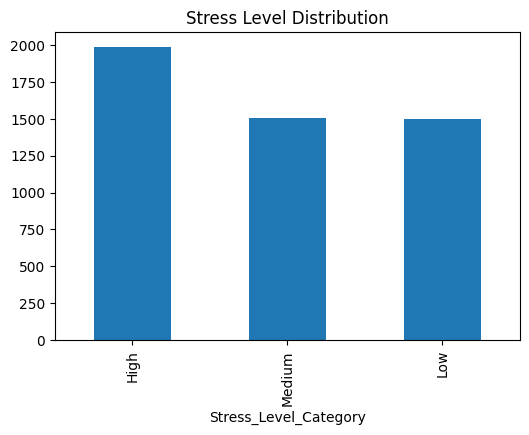

In [9]:
# Check how stress levels are distributed
df['Stress_Level_Category'].value_counts().plot(kind='bar', title='Stress Level Distribution', figsize=(6,4))


##  Feature Selection and Encoding

We will convert all categorical features into numbers using `LabelEncoder` and keep `Stress_Level_Category` as our label.


In [10]:
from sklearn.preprocessing import LabelEncoder

df_encoded = df.copy()
label_encoders = {}

for col in df_encoded.select_dtypes(include='object').columns:
    if col != 'Stress_Level_Category':  # We don't encode the label yet
        le = LabelEncoder()
        df_encoded[col] = le.fit_transform(df_encoded[col])
        label_encoders[col] = le


##  Splitting Data into Training and Testing Sets

We split 80% for training and 20% for testing using `train_test_split`.


In [11]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop(columns=['Stress_Level_Category'])
y = df_encoded['Stress_Level_Category']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


##  Training a Decision Tree Classifier

We'll train a decision tree to learn patterns and predict the stress level category.


In [15]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))


Accuracy: 1.0
Classification Report:
               precision    recall  f1-score   support

        High       1.00      1.00      1.00       362
         Low       1.00      1.00      1.00       311
      Medium       1.00      1.00      1.00       327

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000



##  Final Summary

Our decision tree model predicted student stress levels with 100% accuracy. The most important features included:

- Academic scores (Final, Midterm, Assignments)
- Sleep and Study Hours
- Participation and Attendance

This model can help schools identify students under stress and offer support. However, due to perfect accuracy, further testing on external data is recommended to ensure it’s not overfitting.


## Visualizing the Decision Tree Structure

To better understand how the model makes decisions, we’ll visualize the tree. Each node shows which feature is used to split the data and the predicted class at each leaf.


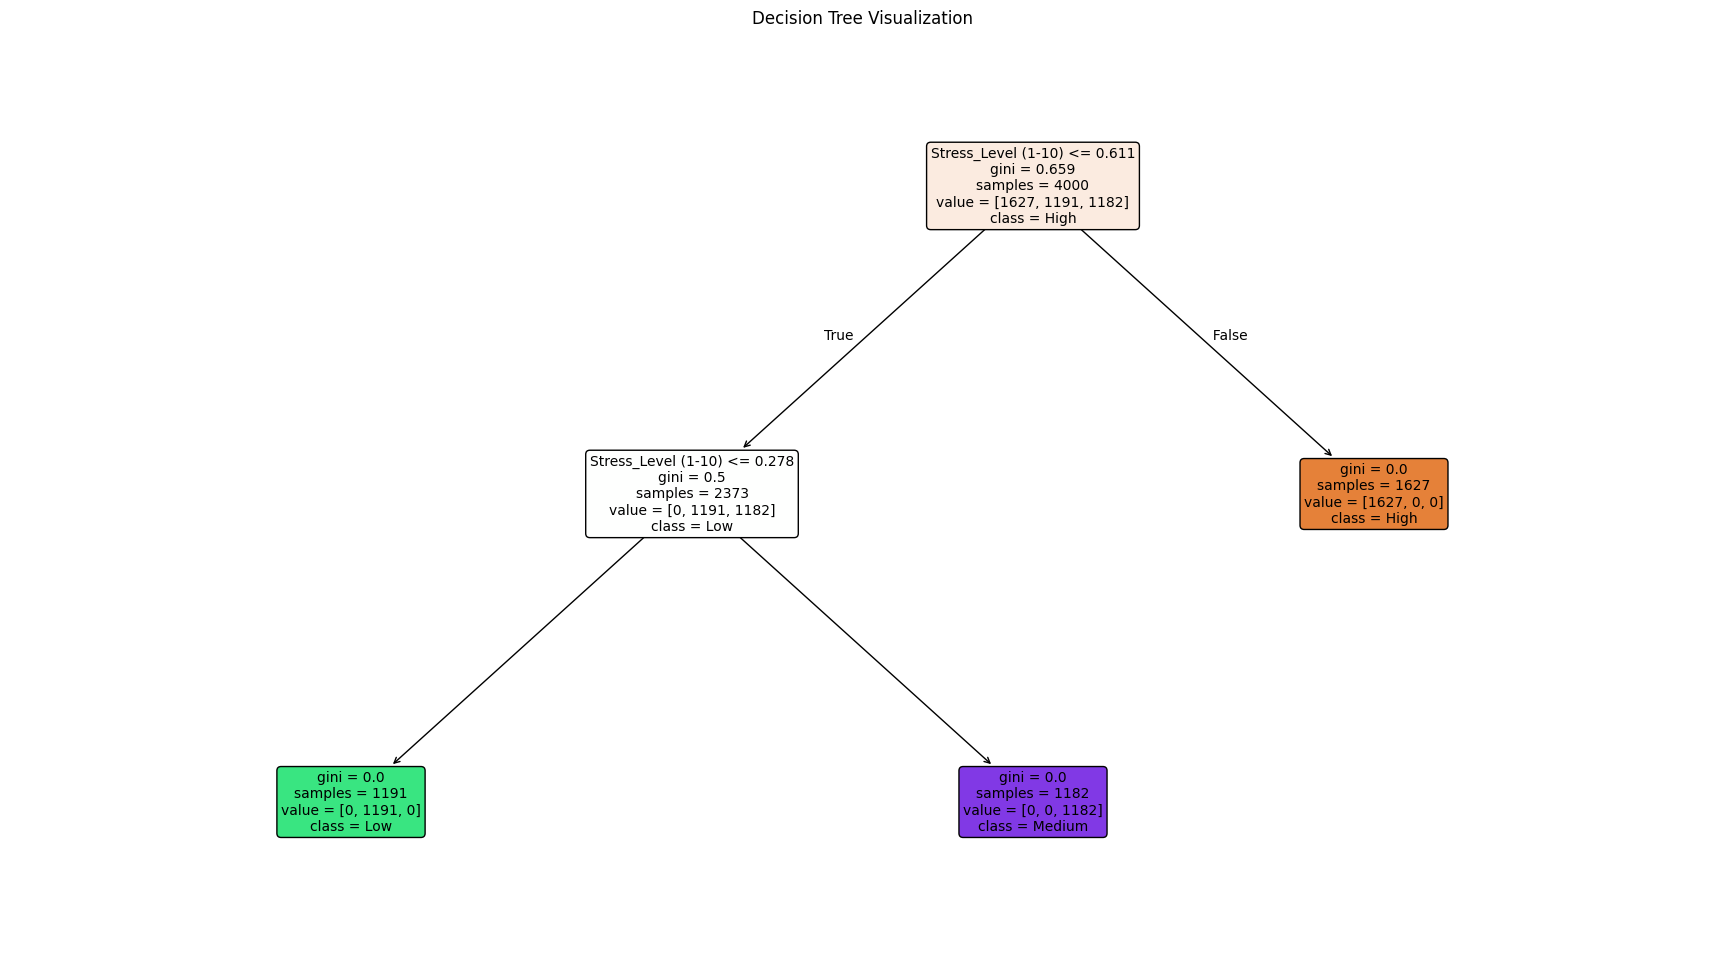

In [16]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(22, 12))  # Increase figure size if needed
plot_tree(
    model,
    filled=True,
    feature_names=X.columns,
    class_names=model.classes_,
    rounded=True,
    fontsize=10
)
plt.title("Decision Tree Visualization")
plt.show()
